In [84]:
import pandas as pd
import torch
import torch.nn.functional as F
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from typing import Tuple, Optional , List, Union

In [85]:
class MEPSimilarityAnalyzer:
    """
    Analyzes voting similarity between Members of European Parliament (MEPs)
    using centered and L2-normalized dot product (cosine similarity).
    Implemented with PyTorch for efficient GPU computation.
    """
    
        
    def __init__(self, rcv_files: Union[str, List[str]], voted_docs_files: Optional[Union[str, List[str]]] = None, device: str = 'cuda'):
        """
        Initialize the analyzer with data files.
        
        Args:
            rcv_files: Path to RCV file (str) or list of paths for multiple sessions
            voted_docs_files: Optional path(s) to voted docs file(s) for metadata
            device: 'cuda' for GPU or 'cpu' for CPU computation
        """
        # Convert to list if single file
        if isinstance(rcv_files, str):
            self.rcv_files = [rcv_files]
        else:
            self.rcv_files = list(rcv_files)
            
            
         # Handle voted_docs_files
        if voted_docs_files is None:
            self.voted_docs_files = [None] * len(self.rcv_files)
        elif isinstance(voted_docs_files, str):
            self.voted_docs_files = [voted_docs_files]
        else:
            self.voted_docs_files = list(voted_docs_files)
                
        self.device = torch.device(device if torch.cuda.is_available() else 'cpu')
        print(f"Using device: {self.device}")
        print(f"Number of files to load: {len(self.rcv_files)}")
        
        self.mep_data = None
        self.vote_matrix = None
        self.similarity_matrix = None
        self.voted_docs = None

        
    def load_data(self) -> pd.DataFrame:
        """
        Load the RCV data from Excel file(s).
        If multiple files, simply stacks all MEPs and all votes together.
        
        Returns:
            DataFrame containing MEP information and votes
        """
        print(f"\n=== Loading data ===")
        
        all_dfs = []
        
        for i, rcv_file in enumerate(self.rcv_files):
            print(f"Loading file {i+1}/{len(self.rcv_files)}: {rcv_file}")
            df = pd.read_excel(rcv_file)
            
            # Add a column to track which file/session this came from
            df['Source_File'] = rcv_file
            df['File_Index'] = i
            
            print(f"  - {len(df)} MEPs, {len(df.columns) - 10} votes")
            all_dfs.append(df)
        
        if len(all_dfs) == 1:
            # Single file
            self.mep_data = all_dfs[0]
        else:
            # Multiple files: stack MEPs vertically
            print(f"\nStacking {len(all_dfs)} datasets...")
            self.mep_data = pd.concat(all_dfs, ignore_index=True)
        
        # Store metadata columns (first 10 columns according to codebook)
        self.metadata_cols = self.mep_data.columns[:10].tolist()
        
        # Vote columns start from column 11 (index 10)
        # Need to find where vote columns end (before Source_File and File_Index)
        vote_end_idx = self.mep_data.columns.get_loc('Source_File')
        self.vote_cols = self.mep_data.columns[10:vote_end_idx].tolist()
        
        print(f"\n=== Dataset summary ===")
        print(f"Total rows (MEPs × Sessions): {len(self.mep_data)}")
        print(f"Total vote columns: {len(self.vote_cols)}")
        print(f"Unique MEPs (by name): {self.mep_data['FullName'].nunique()}")
        
        if len(self.rcv_files) > 1:
            print("\nBreakdown by file:")
            for i, rcv_file in enumerate(self.rcv_files):
                count = (self.mep_data['File_Index'] == i).sum()
                print(f"  File {i+1}: {count} MEPs")
        
        return self.mep_data
    
    def load_vote_metadata(self):
        """
        Load vote metadata from Voted_docs files including sponsor information.
        """
        print("\n=== Loading vote metadata ===")
        
        all_docs = []
        
        for i, docs_file in enumerate(self.voted_docs_files):
            if docs_file is None:
                print(f"Warning: No voted_docs file provided for session {i+1}")
                continue
                
            print(f"Loading metadata file {i+1}: {docs_file}")
            
            try:
                df = pd.read_excel(docs_file)
                df['File_Index'] = i
                all_docs.append(df)
                print(f"  - Loaded {len(df)} vote records")
            except Exception as e:
                print(f"  - Error loading file: {e}")
        
        if len(all_docs) == 0:
            print("No metadata files loaded!")
            return None
        
        # Concatenate all metadata
        self.voted_docs = pd.concat(all_docs, ignore_index=True)
        
        print(f"\nTotal vote records: {len(self.voted_docs)}")
        
        # Check for author_name column
        if 'Author' in self.voted_docs.columns:
            author_col = 'Author'
        elif 'author_name' in self.voted_docs.columns:
            author_col = 'author_name'
        else:
            print("Warning: No 'Author' or 'author_name' column found!")
            print(f"Available columns: {self.voted_docs.columns.tolist()}")
            return self.voted_docs
        
        # Count votes by sponsor
        sponsor_counts = self.voted_docs[author_col].value_counts()
        print(f"\nTop 10 sponsors by number of votes:")
        print(sponsor_counts.head(10))
        
        return self.voted_docs
    
    def encode_votes(self, votes_raw: torch.Tensor) -> torch.Tensor:
        """
        Encode votes according to the scheme:
        1 (for) → +1
        2 (against) → -1
        3 (abstention) → 0
        0, 4, 5, 6 (not MEP, absent, did not vote, motivated) → NaN (to be handled)
        
        Args:
            votes_raw: Tensor of raw vote values
            
        Returns:
            Tensor of encoded votes with NaN for invalid votes
        """
        encoded = torch.full_like(votes_raw, float('nan'), dtype=torch.float32)
        encoded[votes_raw == 1] = 1.0   # For
        encoded[votes_raw == 2] = -1.0  # Against
        encoded[votes_raw == 3] = 0.0   
        encoded[votes_raw == 4] = 0.0 
        encoded[votes_raw == 5] = 0.0 
        encoded[votes_raw == 6] = 0.0 
        # 0 remains as NaN
        
        return encoded
    
    def preprocess_data(self, min_participation_rate: float = 0.1) -> torch.Tensor:
        """
        Preprocess the voting data:
        1. Encode votes
        2. Filter MEPs by minimum participation rate
        3. Center the data (subtract mean for each MEP)
        4. L2 normalize each MEP's voting vector
        
        Args:
            min_participation_rate: Minimum fraction of votes an MEP must participate in
            
        Returns:
            Preprocessed vote matrix (n_meps × n_votes)
        """
        if self.mep_data is None:
            self.load_data()
        
        print("\n=== Preprocessing votes ===")
        
        # Extract vote columns and convert to PyTorch tensor
        votes_raw = torch.tensor(
            self.mep_data[self.vote_cols].values, 
            dtype=torch.float32,
            device=self.device
        )
        n_meps, n_votes = votes_raw.shape
        
        print(f"Initial shape: {n_meps} MEPs × {n_votes} votes")
        
        # Step 1: Encode votes
        print("Step 1: Encoding votes (For→+1, Against→-1, Abstain→0)...")
        votes_encoded = self.encode_votes(votes_raw)
        
        # Step 2: Filter MEPs by participation rate
        print(f"Step 2: Filtering MEPs with participation rate >= {min_participation_rate:.1%}...")
        valid_votes_per_mep = (~torch.isnan(votes_encoded)).sum(dim=1)
        participation_rate = valid_votes_per_mep / n_votes
        
        active_meps_mask = participation_rate >= min_participation_rate
        votes_filtered = votes_encoded[active_meps_mask]
        self.mep_data_filtered = self.mep_data[active_meps_mask.cpu().numpy()].reset_index(drop=True)
        
        print(f"Kept {active_meps_mask.sum().item()} MEPs (removed {(~active_meps_mask).sum().item()})")
        
        # Step 3: Center the data (subtract mean for each MEP)
        print("Step 3: Centering data (subtracting each MEP's mean vote)...")
        
        # Create mask for valid votes
        valid_mask = ~torch.isnan(votes_filtered)
        
        # Replace NaN with 0 for computation
        votes_no_nan = torch.where(valid_mask, votes_filtered, torch.zeros_like(votes_filtered))
        
        # Compute mean for each MEP (only over valid votes)
        valid_counts = valid_mask.sum(dim=1, keepdim=True).clamp(min=1)  # Avoid division by zero
      
        # Center each vote
        mean_votes = votes_no_nan.sum(dim=0, keepdim=True) / valid_counts  # Mean across MEPs (dim=0)
        votes_centered = votes_no_nan - mean_votes
        
        # Step 4: L2 normalize each MEP's voting vector
        print("Step 4: L2 normalizing each MEP's voting vector...")
        
        # Compute L2 norm for each MEP
        norms = torch.norm(votes_centered, dim=1, keepdim=True).clamp(min=1e-8)  # Avoid division by zero
        votes_normalized = votes_centered / norms 
        
        self.vote_matrix = votes_normalized
        
        print(f"\nFinal preprocessed matrix shape: {votes_normalized.shape}")
        print(f"Data is now centered and L2-normalized")        
        return votes_normalized
    
    def compute_similarity_matrix(self, batch_size: Optional[int] = None) -> torch.Tensor:
        """
        Compute the pairwise similarity matrix using dot product
        (which is cosine similarity after centering and L2 normalization).
        Uses batched computation for memory efficiency with large datasets.
        
        Args:
            batch_size: If specified, compute similarity in batches (useful for very large datasets)
            
        Returns:
            Symmetric similarity matrix (n_meps x n_meps)
        """
        if self.vote_matrix is None:
            raise ValueError("Must call preprocess_data() first")
        
        print("\n=== Computing similarity matrix ===")
        print("Using cosine similarity (dot product of centered + L2-normalized vectors)")
        
        n_meps = self.vote_matrix.shape[0]
        
        if batch_size is None or n_meps <= batch_size:
            # Compute all at once: V × V^T
            self.similarity_matrix = torch.mm(self.vote_matrix, self.vote_matrix.t())
        else:
            # Compute in batches to save memory
            print(f"Computing in batches of {batch_size}...")
            self.similarity_matrix = torch.zeros(n_meps, n_meps, device=self.device)
            
            for i in range(0, n_meps, batch_size):
                end_i = min(i + batch_size, n_meps)
                batch = self.vote_matrix[i:end_i]
                self.similarity_matrix[i:end_i] = torch.mm(batch, self.vote_matrix.t())
                
                if (i // batch_size + 1) % 10 == 0:
                    print(f"  Processed {end_i}/{n_meps} MEPs")
        
        print(f"Computed {n_meps} x {n_meps} similarity matrix")
        
        # Verify symmetry
        is_symmetric = torch.allclose(
            self.similarity_matrix, 
            self.similarity_matrix.t(), 
            atol=1e-5
        )
        print(f"Matrix is symmetric: {is_symmetric}")
        
        # Verify diagonal values (should be ~1 for normalized vectors)
        diag_values = torch.diag(self.similarity_matrix)
        print(f"Diagonal values (self-similarity): min={diag_values.min().item():.4f}, "
              f"max={diag_values.max().item():.4f}, mean={diag_values.mean().item():.4f}")
        
        # Statistics (exclude diagonal)
        mask = ~torch.eye(n_meps, dtype=torch.bool, device=self.device)
        off_diag = self.similarity_matrix[mask]
        
        print(f"\nSimilarity statistics (off-diagonal):")
        print(f"  Min: {off_diag.min().item():.4f}")
        print(f"  Max: {off_diag.max().item():.4f}")
        print(f"  Mean: {off_diag.mean().item():.4f}")
        print(f"  Std: {off_diag.std().item():.4f}")
        
        return self.similarity_matrix
    
    def get_most_similar_meps(self, mep_idx: int, top_k: int = 10) -> pd.DataFrame:
        """
        Find the most similar MEPs to a given MEP.
        
        Args:
            mep_idx: Index of the MEP in the filtered dataset
            top_k: Number of most similar MEPs to return
            
        Returns:
            DataFrame with most similar MEPs and their similarity scores
        """
        if self.similarity_matrix is None:
            raise ValueError("Must call compute_similarity_matrix() first")
        
        # Get similarities for this MEP
        similarities = self.similarity_matrix[mep_idx].clone()
        
        # Exclude self (diagonal)
        similarities[mep_idx] = float('-inf')
        
        # Get top k indices
        top_values, top_indices = torch.topk(similarities, k=top_k)
        
        # Convert to CPU for DataFrame creation
        top_values = top_values.cpu().numpy()
        top_indices = top_indices.cpu().numpy()
        
        # Create result DataFrame
        results = []
        for rank, (idx, sim) in enumerate(zip(top_indices, top_values), 1):
            mep_info = self.mep_data_filtered.iloc[idx]
            results.append({
                'Rank': rank,
                'Name': mep_info['FullName'],
                'Country': mep_info['Country'],
                'Party': mep_info['Party'],
                'EPG': mep_info['EPG'],
                'Similarity': sim
            })
        
        return pd.DataFrame(results)
    
    def analyze_by_group(self, group_col: str = 'EPG') -> pd.DataFrame:
        """
        Analyze average within-group and between-group similarities.
        
        Args:
            group_col: Column name to group by (e.g., 'EPG', 'Country', 'Party')
            
        Returns:
            DataFrame with average similarities for each group pair
        """
        if self.similarity_matrix is None:
            raise ValueError("Must call compute_similarity_matrix() first")
        
        groups = self.mep_data_filtered[group_col].values
        unique_groups = unique_groups = sorted([g for g in set(groups) if pd.notna(g)])
        
        results = []
        
        # Move similarity matrix to CPU for numpy indexing
        sim_cpu = self.similarity_matrix.cpu().numpy()
        
        for g1 in unique_groups:
            mask1 = groups == g1
            for g2 in unique_groups:
                mask2 = groups == g2
                
                # Get submatrix
                import numpy as np
                submatrix = sim_cpu[np.ix_(mask1, mask2)]
                
                # If same group, exclude diagonal
                if g1 == g2:
                    mask = ~np.eye(submatrix.shape[0], dtype=bool)
                    avg_sim = submatrix[mask].mean()
                else:
                    avg_sim = submatrix.mean()
                
                results.append({
                    'Group1': g1,
                    'Group2': g2,
                    'Count1': np.sum(mask1),
                    'Count2': np.sum(mask2),
                    'Avg_Similarity': avg_sim
                })
        
        return pd.DataFrame(results)
    
    def visualize_similarity_matrix(self, figsize=(12, 10), sample_size: Optional[int] = None):
        """
        Visualize the similarity matrix as a heatmap.
        
        Args:
            figsize: Figure size
            sample_size: If specified, randomly sample this many MEPs for visualization
        """
        if self.similarity_matrix is None:
            raise ValueError("Must call compute_similarity_matrix() first")
        
        # Move to CPU for visualization
        sim_matrix = self.similarity_matrix.cpu().numpy()
        
        # Sample if requested
        if sample_size is not None and sample_size < len(sim_matrix):
            import numpy as np
            indices = np.random.choice(len(sim_matrix), sample_size, replace=False)
            sim_matrix = sim_matrix[np.ix_(indices, indices)]
            title_suffix = f" (Random sample of {sample_size} MEPs)"
        else:
            title_suffix = ""
        
        plt.figure(figsize=figsize)
        sns.heatmap(sim_matrix, cmap='RdBu_r', center=0, 
                    vmin=-1, vmax=1, square=True,
                    cbar_kws={'label': 'Cosine Similarity'})
        plt.title(f'MEP Voting Similarity Matrix{title_suffix}')
        plt.xlabel('MEP Index')
        plt.ylabel('MEP Index')
        plt.tight_layout()
        plt.show()
    
    def visualize_group_similarity(self, group_col: str = 'EPG', figsize=(10, 8)):
        """
        Visualize average similarity between political groups.
        
        Args:
            group_col: Column to group by
            figsize: Figure size
        """
        df = self.analyze_by_group(group_col)
        
        # Create pivot table for heatmap
        pivot = df.pivot(index='Group1', columns='Group2', values='Avg_Similarity')
        
        plt.figure(figsize=figsize)
        sns.heatmap(pivot, annot=True, fmt='.3f', cmap='RdBu_r', center=0,
                    vmin=-1, vmax=1, square=True,
                    cbar_kws={'label': 'Average Cosine Similarity'})
        plt.title(f'Average Voting Similarity by {group_col}')
        plt.tight_layout()
        plt.show()
    
    def save_similarity_matrix(self, filename: str):
        """Save similarity matrix to disk."""
        torch.save(self.similarity_matrix.cpu(), filename)
        print(f"Similarity matrix saved to '{filename}'")
    
    def load_similarity_matrix(self, filename: str):
        """Load similarity matrix from disk."""
        self.similarity_matrix = torch.load(filename, map_location=self.device)
        print(f"Similarity matrix loaded from '{filename}'")

    
    def compute_mds(self, n_components: int = 2) -> torch.Tensor:
        """
        Compute Multidimensional Scaling (MDS) coordinates from similarity matrix.
        Uses direct eigenvalue decomposition of the similarity matrix S.
        
        Since S is symmetric positive semi-definite, we have:
        S = U Λ U^T = (Λ^0.5 U^T)^T (Λ^0.5 U^T)
        
        So we can take X = Λ^0.5 U^T (selecting top k components)
        such that S ≈ X^T X
        
        Args:
            n_components: Number of dimensions for the embedding (typically 2 for visualization)
            
        Returns:
            Tensor of shape (n_meps, n_components) containing the MDS coordinates
        """
        if self.similarity_matrix is None:
            raise ValueError("Must call compute_similarity_matrix() first")
        
        print(f"\n=== Computing MDS with {n_components} components ===")
        print("Method: Direct eigenvalue decomposition of similarity matrix")
        print("Formula: X = I_{kxn} Λ^{0.5} U^T")
        
        S = self.similarity_matrix
        n = S.shape[0]
        
        # Step 1: Eigenvalue decomposition of similarity matrix
        # S = U Λ U^T
        print("\nComputing eigenvalue decomposition of similarity matrix...")
        eigenvalues, eigenvectors = torch.linalg.eigh(S)
        
        # Step 2: Sort eigenvalues in descending order
        idx = torch.argsort(eigenvalues, descending=True)
        eigenvalues = eigenvalues[idx]
        eigenvectors = eigenvectors[:, idx]
        
        print(f"Top 10 eigenvalues: {eigenvalues[:10].cpu().numpy()}")
        
        # Step 3: Select top k components
        # Take only non-negative eigenvalues (there might be small negative ones due to numerical errors)
        positive_mask = eigenvalues > 1e-10
        n_positive = positive_mask.sum().item()
        
        if n_positive < n_components:
            print(f"Warning: Only {n_positive} positive eigenvalues found, using all of them")
            n_components = n_positive
        
        eigenvalues_k = eigenvalues[:n_components]
        eigenvectors_k = eigenvectors[:, :n_components]
        
        # Ensure eigenvalues are non-negative (clamp small negative values to 0)
        eigenvalues_k = torch.clamp(eigenvalues_k, min=0)
        
        # Step 4: Compute X = Λ^{0.5} U^T
        # This gives us X such that X^T X ≈ S
        # Transposed to get (n_meps, n_components) instead of (n_components, n_meps)
        Lambda_sqrt = torch.diag(torch.sqrt(eigenvalues_k))
        X = (Lambda_sqrt @ eigenvectors_k.T).T  # Transpose to get (n, k)
        
        self.mds_coordinates = X.cpu().numpy()
        
        # Compute explained variance
        total_variance = eigenvalues[eigenvalues > 0].sum()
        explained_variance = eigenvalues_k.sum() / total_variance * 100
        
        print(f"\nMDS complete!")
        print(f"Coordinates shape: {self.mds_coordinates.shape}")
        print(f"Explained variance by top {n_components} components: {explained_variance.item():.2f}%")
        print(f"Number of positive eigenvalues: {n_positive}")
        
        # Verify reconstruction (optional sanity check)
        S_reconstructed = X @ X.T
        reconstruction_error = torch.norm(S - S_reconstructed, 'fro') / torch.norm(S, 'fro')
        print(f"Relative reconstruction error: {reconstruction_error.item():.6f}")
        
        return X
    
    def plot_mds(self, color_by: str = 'EPG', figsize=(14, 10), save_path: Optional[str] = None, 
                 sample_size: Optional[int] = None, alpha: float = 0.6):
        """
        Plot MDS coordinates colored by a specified attribute.
        
        Args:
            color_by: Column to color points by ('EPG', 'Country', 'Party')
            figsize: Figure size
            save_path: If provided, save figure to this path
            sample_size: If provided, randomly sample this many MEPs for clearer visualization
            alpha: Transparency of points
        """
        if self.mds_coordinates is None:
            raise ValueError("Must call compute_mds() first")
        
        import numpy as np
        
        # Get coordinates and labels
        X = self.mds_coordinates
        labels = self.mep_data_filtered[color_by].values
        
        # Handle sampling if requested
        if sample_size is not None and sample_size < len(X):
            indices = np.random.choice(len(X), sample_size, replace=False)
            X = X[indices]
            labels = labels[indices]
            title_suffix = f" (Random sample of {sample_size} MEPs)"
        else:
            title_suffix = ""
        
        # Create figure
        fig, ax = plt.subplots(figsize=figsize)
        
        # Get unique labels (excluding NaN)
        unique_labels = sorted([l for l in set(labels) if pd.notna(l)])
        
        # Create color map
        if color_by == 'EPG':
            # Use specific colors for political groups
            color_map = {
                'EPP': '#3399FF',      # Blue (center-right)
                'S&D': '#FF0000',      # Red (center-left)
                'Renew': '#FFDD00',    # Yellow (liberal)
                'Greens/EFA': '#00CC00', # Green
                'ID': '#000066',       # Dark blue (far-right)
                'ECR': '#0066CC',      # Blue (right)
                'GUE/NGL': '#990000',  # Dark red (far-left)
                'NI': '#999999',       # Gray (non-attached)
            }
            # Add any missing groups with random colors
            for label in unique_labels:
                if label not in color_map:
                    color_map[label] = plt.cm.tab20(len(color_map) % 20)
        else:
            # Use colormap for countries or parties
            cmap = plt.cm.tab20 if len(unique_labels) <= 20 else plt.cm.hsv
            color_map = {label: cmap(i / len(unique_labels)) for i, label in enumerate(unique_labels)}
        
        # Plot each group
        for label in unique_labels:
            mask = labels == label
            ax.scatter(X[mask, 0], X[mask, 1], 
                      c=[color_map[label]], 
                      label=label, 
                      alpha=alpha, 
                      s=50,
                      edgecolors='black',
                      linewidths=0.5)
        
        # Formatting
        ax.set_xlabel('MDS Dimension 1', fontsize=12)
        ax.set_ylabel('MDS Dimension 2', fontsize=12)
        ax.set_title(f'MDS Projection of MEPs colored by {color_by}{title_suffix}', fontsize=14, fontweight='bold')
        ax.grid(True, alpha=0.3)
        
        # Legend
        if len(unique_labels) <= 15:
            ax.legend(loc='center left', bbox_to_anchor=(1, 0.5), fontsize=10)
        else:
            print(f"Too many categories ({len(unique_labels)}) for legend. Legend omitted.")
        
        plt.tight_layout()
        
        if save_path:
            plt.savefig(save_path, dpi=300, bbox_inches='tight')
            print(f"Figure saved to {save_path}")
        
        plt.show()
    
    def compare_mds_colorings(self, figsize=(20, 8), sample_size: Optional[int] = None):
        """
        Create side-by-side plots comparing EPG and Country colorings.
        
        Args:
            figsize: Figure size
            sample_size: If provided, sample this many MEPs
        """
        if self.mds_coordinates is None:
            raise ValueError("Must call compute_mds() first")
        
        import numpy as np
        
        # Get coordinates
        X = self.mds_coordinates
        epg_labels = self.mep_data_filtered['EPG'].values
        country_labels = self.mep_data_filtered['Country'].values
        
        # Handle sampling
        if sample_size is not None and sample_size < len(X):
            indices = np.random.choice(len(X), sample_size, replace=False)
            X = X[indices]
            epg_labels = epg_labels[indices]
            country_labels = country_labels[indices]
            title_suffix = f" (Sample: {sample_size} MEPs)"
        else:
            title_suffix = ""
        
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=figsize)
        
        # Plot 1: Colored by EPG
        unique_epg = sorted([l for l in set(epg_labels) if pd.notna(l)])
        epg_color_map = {
            'EPP': '#3399FF', 'S&D': '#FF0000', 'Renew': '#FFDD00',
            'Greens/EFA': '#00CC00', 'ID': '#000066', 'ECR': '#0066CC',
            'GUE/NGL': '#990000', 'NI': '#999999',
        }
        for label in unique_epg:
            if label not in epg_color_map:
                epg_color_map[label] = plt.cm.tab20(len(epg_color_map) % 20)
        
        for label in unique_epg:
            mask = epg_labels == label
            ax1.scatter(X[mask, 0], X[mask, 1], 
                       c=[epg_color_map[label]], 
                       label=label, alpha=0.6, s=50,
                       edgecolors='black', linewidths=0.5)
        
        ax1.set_xlabel('MDS Dimension 1', fontsize=11)
        ax1.set_ylabel('MDS Dimension 2', fontsize=11)
        ax1.set_title(f'Colored by Political Group (EPG){title_suffix}', fontsize=12, fontweight='bold')
        ax1.grid(True, alpha=0.3)
        ax1.legend(loc='best', fontsize=9)
        
        # Plot 2: Colored by Country
        unique_countries = sorted([l for l in set(country_labels) if pd.notna(l)])
        cmap = plt.cm.tab20 if len(unique_countries) <= 20 else plt.cm.hsv
        country_color_map = {label: cmap(i / len(unique_countries)) 
                            for i, label in enumerate(unique_countries)}
        
        for label in unique_countries:
            mask = country_labels == label
            ax2.scatter(X[mask, 0], X[mask, 1], 
                       c=[country_color_map[label]], 
                       label=label, alpha=0.6, s=50,
                       edgecolors='black', linewidths=0.5)
        
        ax2.set_xlabel('MDS Dimension 1', fontsize=11)
        ax2.set_ylabel('MDS Dimension 2', fontsize=11)
        ax2.set_title(f'Colored by Country{title_suffix}', fontsize=12, fontweight='bold')
        ax2.grid(True, alpha=0.3)
        
        if len(unique_countries) <= 15:
            ax2.legend(loc='best', fontsize=8, ncol=2)
        
        plt.tight_layout()
        plt.show()

    def compute_support_matrix(self, sponsor_col: str = 'Author', min_votes: int = 10):
        """
        Compute support matrix: how each political group votes on proposals 
        sponsored by each political group.
        
        Args:
            sponsor_col: Column name for sponsor ('Author' or 'author_name')
            min_votes: Minimum number of votes a sponsor must have to be included
            
        Returns:
            DataFrame with support rates (rows=sponsors, cols=voter groups)
        """
        if self.voted_docs is None:
            self.load_vote_metadata()
        
        if self.voted_docs is None:
            raise ValueError("No vote metadata available")
        
        if self.mep_data_filtered is None:
            raise ValueError("Must call preprocess_data() first")
        
        print(f"\n=== Computing Support Matrix ===")
        print(f"Sponsor column: {sponsor_col}")
        
        # Create mapping from various names to standard short names
        epg_name_mapping = {
            'Confederal Group of the European United Left - Nordic Green Left': 'GUE/NGL',
            'EUL/NGL': 'GUE/NGL',
            'The Left': 'GUE/NGL',
            'European Conservatives and Reformists Group': 'ECR',
            'ECR': 'ECR',
            "Group of the European People's Party (Christian Democrats)": 'EPP',
            'EPP': 'EPP',
            'Europe of Freedom and Direct Democracy Group': 'EFDD',
            'EFDD': 'EFDD',
            'Europe of Nations and Freedom Group': 'ENF',
            'ENF': 'ENF',
            'IDG': 'ID',
            'ID': 'ID',
            'Greens/EFA': 'Greens/EFA',
            'Greens/ EFA': 'Greens/EFA',
            'Group of the Greens/European Free Alliance': 'Greens/EFA',
            'Group of the Alliance of Liberals and Democrats for Europe': 'ALDE/Renew',
            'ALDE': 'ALDE/Renew',
            'Renew': 'ALDE/Renew',
            'REG': 'ALDE/Renew',
            'Group of the Progressive Alliance of Socialists and Democrats in the European Parliament': 'S&D',
            'S&D': 'S&D',
            'Non-attached Members': 'NI',
            'NI': 'NI',
        }
        
        # Map voter group names to standard names
        voter_groups_original = sorted([g for g in self.mep_data_filtered['EPG'].unique() if pd.notna(g)])
        voter_groups = sorted(list(set([epg_name_mapping.get(g, g) for g in voter_groups_original])))
        
        print(f"Voter groups (standardized): {voter_groups}")
        
        # Initialize support matrix
        support_data = []
        
        # Determine vote ID column name
        if 'Vote ID' in self.voted_docs.columns:
            vote_id_col = 'Vote ID'
        elif 'euro_act_id' in self.voted_docs.columns:
            vote_id_col = 'euro_act_id'
        else:
            print(f"Available columns in voted_docs: {self.voted_docs.columns.tolist()}")
            raise ValueError("No 'Vote ID' or 'euro_act_id' column found in voted_docs")
        
        print(f"Using vote ID column: {vote_id_col}")
        
        # Get sponsors with enough votes
        sponsors = self.voted_docs[sponsor_col].value_counts()
        sponsors = sponsors[sponsors >= min_votes].index.tolist()
        
        # Map sponsor names and filter for EPG sponsors
        sponsors_mapped = [(s, epg_name_mapping.get(s, s)) for s in sponsors]
        sponsors_filtered = [(orig, mapped) for orig, mapped in sponsors_mapped 
                            if mapped in voter_groups]
        
        print(f"Analyzing {len(sponsors_filtered)} EPG sponsors with >= {min_votes} votes")
        
        # Sort voted_docs by Vote ID to match column order in RCV files
        voted_docs_sorted = self.voted_docs.sort_values(vote_id_col).reset_index(drop=True)
        
        print(f"Total votes in metadata: {len(voted_docs_sorted)}")
        print(f"Total vote columns in data: {len(self.vote_cols)}")
        
        # Match by position
        for sponsor_orig, sponsor_std in sponsors_filtered:
            # Get vote records sponsored by this group
            sponsor_mask = voted_docs_sorted[sponsor_col] == sponsor_orig
            sponsor_vote_indices = sponsor_mask[sponsor_mask].index.tolist()
            
            if len(sponsor_vote_indices) == 0:
                continue
            
            # These indices correspond to column positions in vote_cols
            valid_indices = [i for i in sponsor_vote_indices if i < len(self.vote_cols)]
            
            if len(valid_indices) == 0:
                print(f"  Warning: No valid vote indices for sponsor {sponsor_std}")
                continue
            
            print(f"  {sponsor_std}: {len(valid_indices)} votes")
            
            # Get vote column names for these positions
            vote_columns = [self.vote_cols[i] for i in valid_indices]
            
            # Get votes for these proposals from filtered MEPs
            votes_for_sponsor = self.mep_data_filtered[vote_columns].values
            
            # Compute support rate for each EPG (using standardized names)
            row_data = {'Sponsor': sponsor_std, 'N_Votes': len(valid_indices)}
            
            for voter_group_std in voter_groups:
                # Get all original names that map to this standard name
                matching_original_names = [orig for orig in voter_groups_original 
                                          if epg_name_mapping.get(orig, orig) == voter_group_std]
                
                # Get MEPs from any of these matching groups
                epg_mask = self.mep_data_filtered['EPG'].isin(matching_original_names)
                
                if epg_mask.sum() == 0:
                    row_data[voter_group_std] = np.nan
                    continue
                
                epg_votes = votes_for_sponsor[epg_mask]
                
                # Count For votes (encoded as 1)
                n_for = np.sum(epg_votes == 1)
                n_against = np.sum(epg_votes == 2)
                n_abstain = np.sum(epg_votes == 3)
                n_total = n_for + n_against + n_abstain
                
                support_rate = n_for / n_total if n_total > 0 else np.nan
                row_data[voter_group_std] = support_rate
            
            support_data.append(row_data)
        
        if len(support_data) == 0:
            raise ValueError("No support data computed.")
        
        support_df = pd.DataFrame(support_data)
        support_df = support_df.set_index('Sponsor')
        
        print(f"\nSupport matrix computed: {support_df.shape}")
        print(f"Sponsors: {len(support_df)}, Voter groups: {len(voter_groups)}")
        
        self.support_matrix = support_df
        return support_df
        
    def visualize_support_heatmap(self, figsize=(12, 10), annot=True):
        """
        Visualize support matrix as a heatmap.
        
        Args:
            figsize: Figure size
            annot: Whether to annotate cells with values
        """
        if not hasattr(self, 'support_matrix') or self.support_matrix is None:
            raise ValueError("Must call compute_support_matrix() first")
        
        # Remove N_Votes column for visualization
        plot_data = self.support_matrix.drop('N_Votes', axis=1, errors='ignore')
        
        plt.figure(figsize=figsize)
        sns.heatmap(plot_data, annot=annot, fmt='.2f', cmap='RdYlGn', 
                    vmin=0, vmax=1, center=0.5,
                    cbar_kws={'label': 'Support Rate (% voting For)'})
        plt.title('Political Group Support Matrix\n(Rows: Sponsors, Columns: Voter Groups)', 
                  fontsize=14, fontweight='bold')
        plt.xlabel('Voter Group (EPG)', fontsize=12)
        plt.ylabel('Sponsor Group', fontsize=12)
        plt.tight_layout()
        plt.show()
    
    def analyze_group_loyalty_and_alliances(self):
        """
        Analyze in-group loyalty and cross-group alliances.
        
        Returns:
            Dictionary with loyalty scores and alliance patterns
        """
        if not hasattr(self, 'support_matrix') or self.support_matrix is None:
            raise ValueError("Must call compute_support_matrix() first")
        
        print("\n=== Group Loyalty and Alliance Analysis ===")
        
        support_df = self.support_matrix.drop('N_Votes', axis=1, errors='ignore')
        
        # Convert to numpy array for easier indexing
        import numpy as np
        support_array = support_df.values
        row_labels = support_df.index.tolist()
        col_labels = support_df.columns.tolist()
        
        results = {
            'in_group_loyalty': {},
            'strongest_alliances': [],
            'strongest_oppositions': [],
            'asymmetric_alliances': []
        }
        
        # 1. In-group loyalty (diagonal)
        print("\n1. In-Group Loyalty (do MEPs support their own group's proposals?):")
        for i, row_group in enumerate(row_labels):
            if row_group in col_labels:
                j = col_labels.index(row_group)
                loyalty = support_array[i, j]
                if not np.isnan(loyalty):
                    results['in_group_loyalty'][row_group] = float(loyalty)
                    print(f"  {row_group}: {loyalty:.1%}")
        
        # 2. Strongest cross-group alliances
        print("\n2. Strongest Cross-Group Alliances (support > 60%):")
        for i, sponsor in enumerate(row_labels):
            for j, voter in enumerate(col_labels):
                if sponsor != voter:
                    support = support_array[i, j]
                    if not np.isnan(support) and support > 0.6:
                        results['strongest_alliances'].append({
                            'Sponsor': sponsor,
                            'Supporter': voter,
                            'Support_Rate': float(support)
                        })
                        print(f"  {voter} supports {sponsor}: {support:.1%}")
        
        # 3. Strongest oppositions (support < 30%)
        print("\n3. Strongest Oppositions (support < 30%):")
        for i, sponsor in enumerate(row_labels):
            for j, voter in enumerate(col_labels):
                if sponsor != voter:
                    support = support_array[i, j]
                    if not np.isnan(support) and support < 0.3:
                        results['strongest_oppositions'].append({
                            'Sponsor': sponsor,
                            'Opponent': voter,
                            'Support_Rate': float(support)
                        })
                        print(f"  {voter} opposes {sponsor}: {support:.1%}")
        
        # 4. Asymmetric alliances (A supports B more than B supports A)
        print("\n4. Asymmetric Alliances (difference > 20%):")
        checked_pairs = set()
        
        for i, group1 in enumerate(row_labels):
            if group1 not in col_labels:
                continue
            j1 = col_labels.index(group1)
            
            for k, group2 in enumerate(col_labels):
                if group2 not in row_labels or group1 == group2:
                    continue
                
                # Avoid checking same pair twice
                pair = tuple(sorted([group1, group2]))
                if pair in checked_pairs:
                    continue
                checked_pairs.add(pair)
                
                i2 = row_labels.index(group2)
                
                # group1 votes on group2's proposals: row=group2, col=group1
                support_1_to_2 = support_array[i2, j1]
                # group2 votes on group1's proposals: row=group1, col=group2
                support_2_to_1 = support_array[i, k]
                
                if not np.isnan(support_1_to_2) and not np.isnan(support_2_to_1):
                    asymmetry = abs(support_1_to_2 - support_2_to_1)
                    if asymmetry > 0.2:
                        results['asymmetric_alliances'].append({
                            'Group1': group1,
                            'Group2': group2,
                            'G1_supports_G2': float(support_1_to_2),
                            'G2_supports_G1': float(support_2_to_1),
                            'Asymmetry': float(asymmetry)
                        })
                        print(f"  {group1} → {group2}: {support_1_to_2:.1%}, "
                              f"{group2} → {group1}: {support_2_to_1:.1%} "
                              f"(Δ = {asymmetry:.1%})")
        
        return results

In [86]:
# Step 1: Initialize with BOTH rcv_files AND voted_docs_files
analyzer_multi = MEPSimilarityAnalyzer(
    rcv_files=[
        'EP-voting-data/EP8_RCVs_2019_06_25.xlsx',
        'EP-voting-data/EP9_RCVs_2022_06_22.xlsx'
    ],
    voted_docs_files=[
        'EP-voting-data/EP8_Voted_docs.xlsx',
        'EP-voting-data/EP9_Voted_docs.xlsx'
    ],
    device='cpu'
)

analyzer_multi.load_data()
analyzer_multi.preprocess_data(min_participation_rate=0.3)  # Lower threshold since combined
analyzer_multi.compute_similarity_matrix()

print("\n=== Political group cohesion across EP8 and EP9 ===")
group_sim = analyzer_multi.analyze_by_group('EPG')
within_group = group_sim[group_sim['Group1'] == group_sim['Group2']]
print(within_group[['Group1', 'Count1', 'Avg_Similarity']].to_string(index=False))


Using device: cpu
Number of files to load: 2

=== Loading data ===
Loading file 1/2: EP-voting-data/EP8_RCVs_2019_06_25.xlsx
  - 858 MEPs, 10253 votes
Loading file 2/2: EP-voting-data/EP9_RCVs_2022_06_22.xlsx
  - 811 MEPs, 13461 votes

Stacking 2 datasets...

=== Dataset summary ===
Total rows (MEPs × Sessions): 1669
Total vote columns: 10251
Unique MEPs (by name): 811

Breakdown by file:
  File 1: 858 MEPs
  File 2: 811 MEPs

=== Preprocessing votes ===
Initial shape: 1669 MEPs × 10251 votes
Step 1: Encoding votes (For→+1, Against→-1, Abstain→0)...
Step 2: Filtering MEPs with participation rate >= 30.0%...
Kept 1520 MEPs (removed 149)
Step 3: Centering data (subtracting each MEP's mean vote)...
Step 4: L2 normalizing each MEP's voting vector...

Final preprocessed matrix shape: torch.Size([1520, 10251])
Data is now centered and L2-normalized

=== Computing similarity matrix ===
Using cosine similarity (dot product of centered + L2-normalized vectors)
Computed 1520 x 1520 similarity ma

In [87]:
print("\n=== Political group cohesion across EP8 and EP9 ===")
group_sim = analyzer_multi.analyze_by_group('EPG')
within_group = group_sim[group_sim['Group1'] == group_sim['Group2']]
print(within_group[['Group1', 'Count1', 'Avg_Similarity']].to_string(index=False))


=== Political group cohesion across EP8 and EP9 ===
                                                                                  Group1  Count1  Avg_Similarity
                        Confederal Group of the European United Left - Nordic Green Left      51        0.628182
                                                                                     ECR      64        0.629186
                                                                                     EPP     179        0.776097
                                            Europe of Freedom and Direct Democracy Group      42        0.234694
                                                     Europe of Nations and Freedom Group      35        0.412162
                                             European Conservatives and Reformists Group      73        0.493422
                                                                              Greens/EFA      72        0.898413
                              Group of the 


=== Computing MDS with 2 components ===
Method: Direct eigenvalue decomposition of similarity matrix
Formula: X = I_{kxn} Λ^{0.5} U^T

Computing eigenvalue decomposition of similarity matrix...
Top 10 eigenvalues: [316.58914  278.53534  145.30173  121.349014  40.567554  33.707355
  31.091452  27.1568    21.842615  20.3453  ]

MDS complete!
Coordinates shape: (1520, 2)
Explained variance by top 2 components: 39.15%
Number of positive eigenvalues: 1520
Relative reconstruction error: 0.442204

Creating visualizations...

1. Plotting MEPs colored by Political Group (EPG)...
Too many categories (17) for legend. Legend omitted.


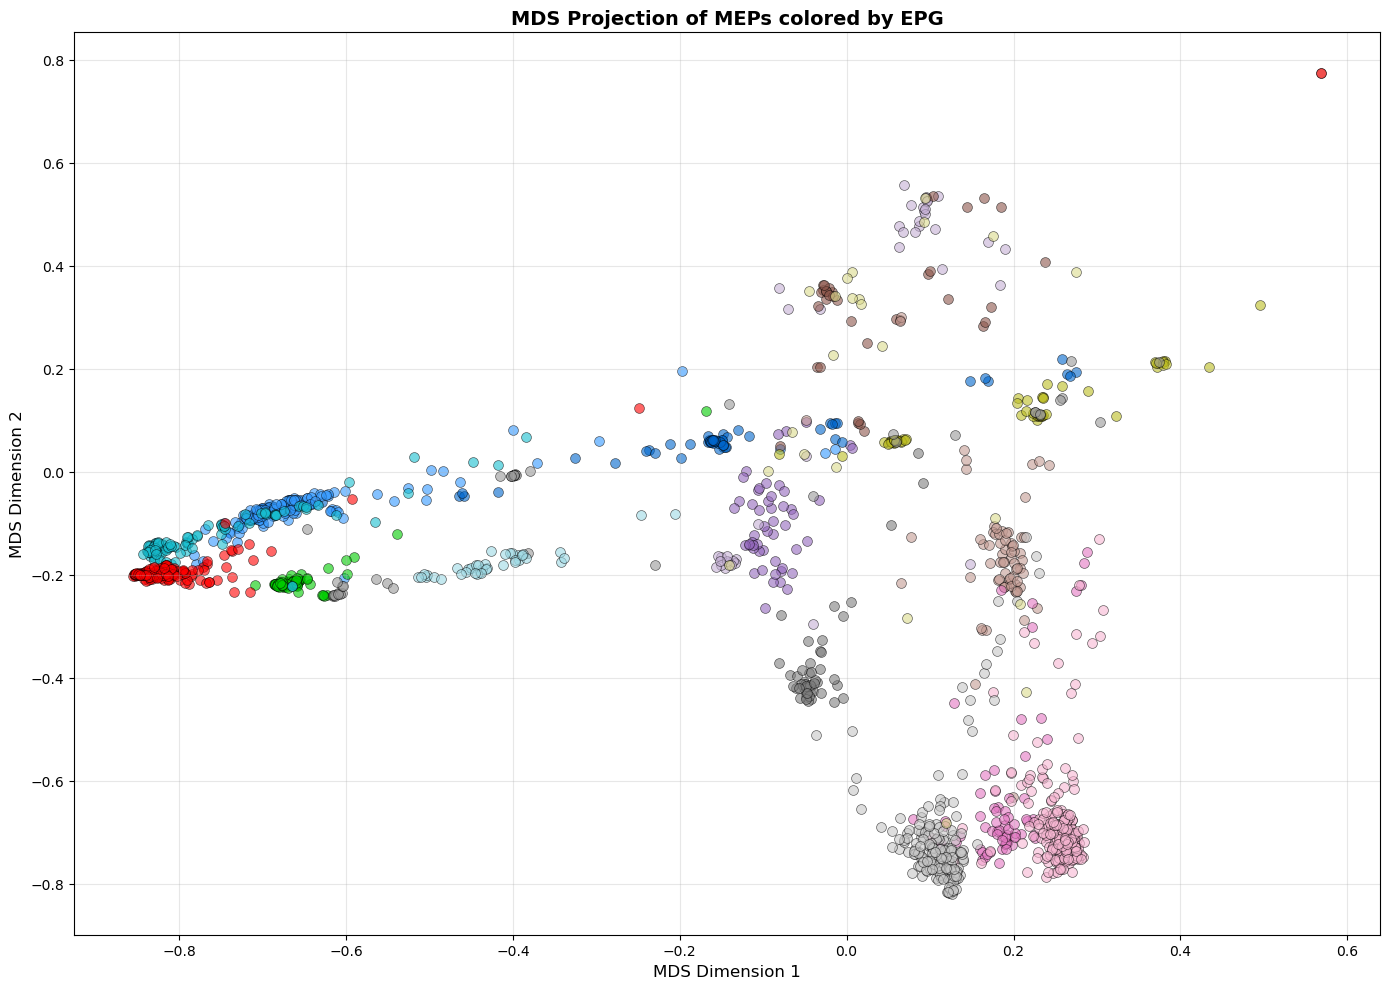


2. Plotting MEPs colored by Country...
Too many categories (28) for legend. Legend omitted.


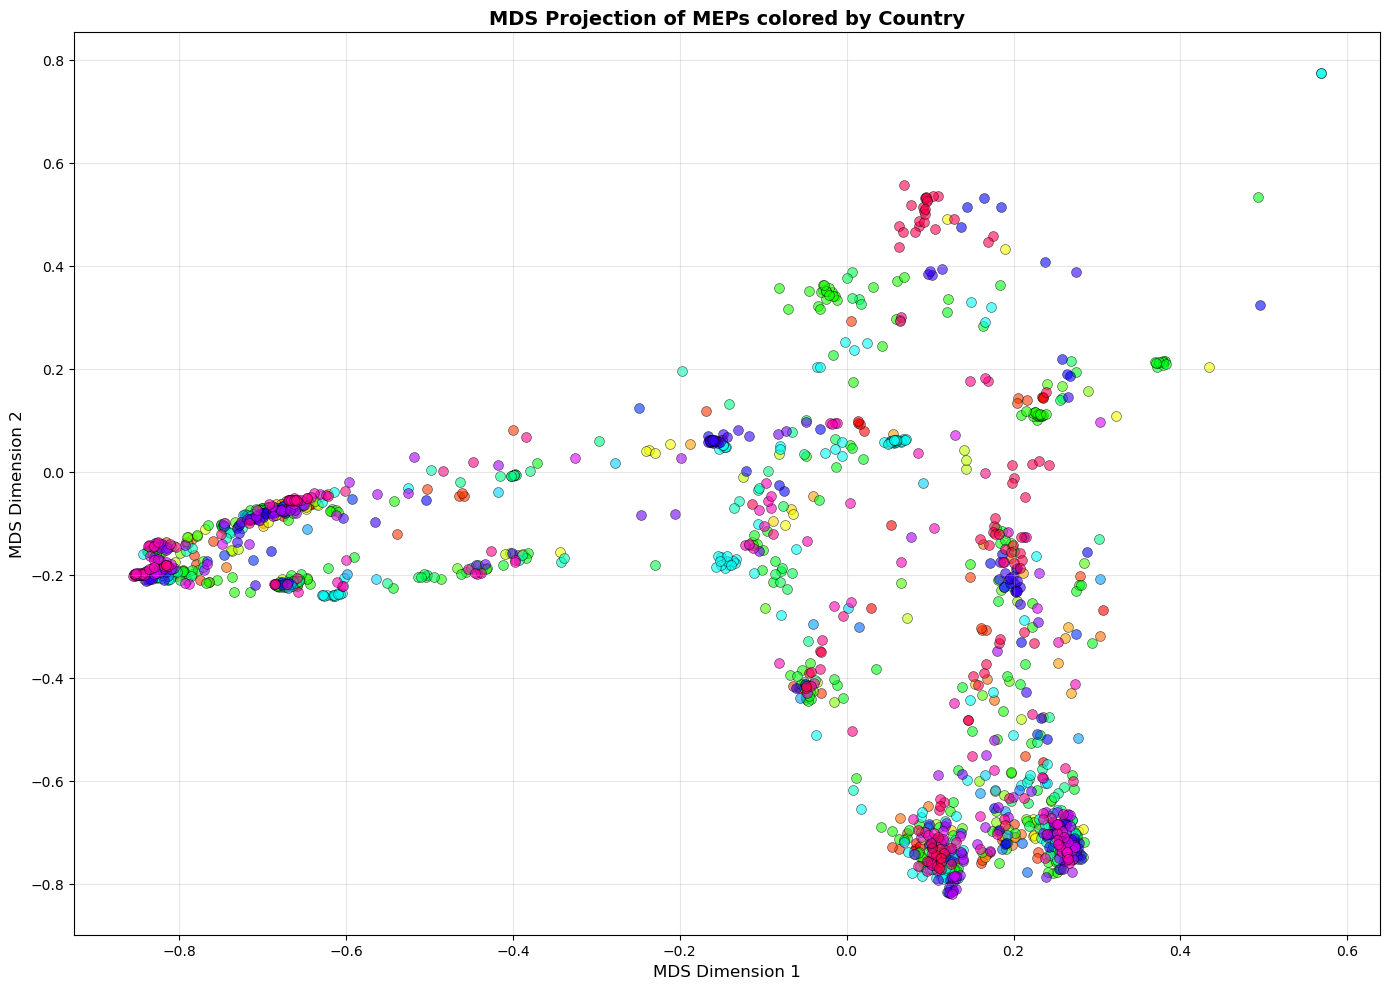


3. Creating side-by-side comparison...


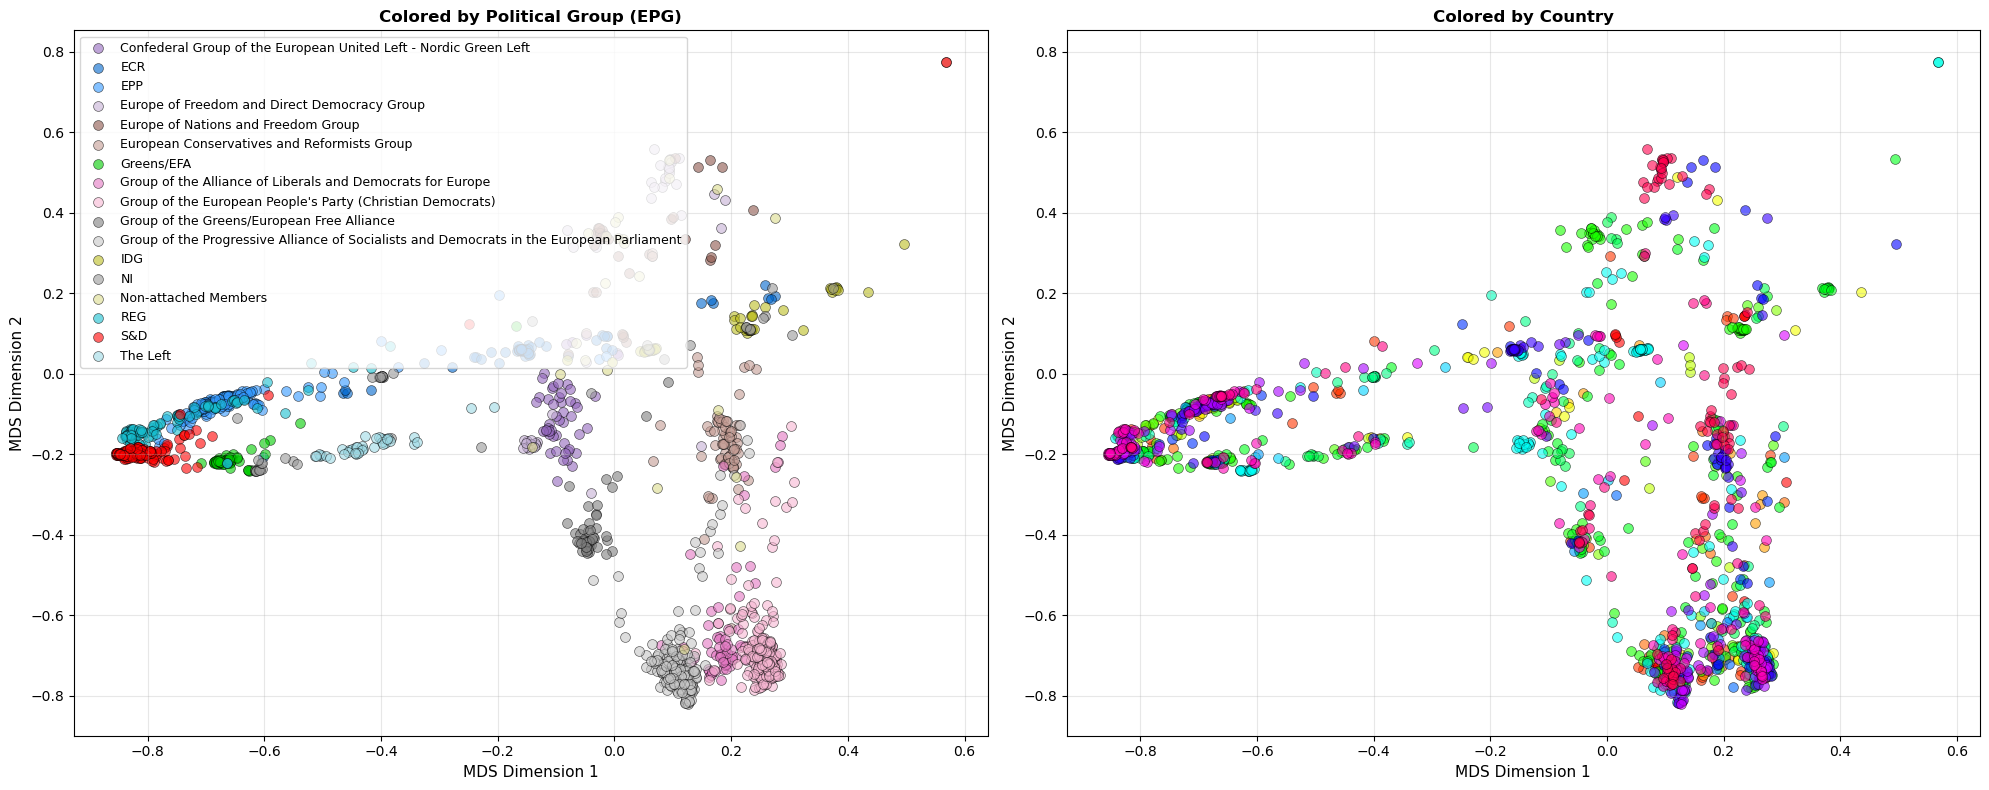

In [88]:
# Compute MDS coordinates
analyzer_multi.compute_mds(n_components=2)

# Visualizations
print("\n" + "="*70)
print("Creating visualizations...")
print("="*70)

# Plot 1: Colored by Political Group
print("\n1. Plotting MEPs colored by Political Group (EPG)...")
analyzer_multi.plot_mds(color_by='EPG', sample_size=None)  # Use all MEPs

# Plot 2: Colored by Country
print("\n2. Plotting MEPs colored by Country...")
analyzer_multi.plot_mds(color_by='Country', sample_size=None)

# Plot 3: Side-by-side comparison
print("\n3. Creating side-by-side comparison...")
analyzer_multi.compare_mds_colorings(sample_size=None)


Using device: cpu
Number of files to load: 1

=== Loading data ===
Loading file 1/1: EP-voting-data/EP9_RCVs_2022_06_22.xlsx
  - 811 MEPs, 13461 votes

=== Dataset summary ===
Total rows (MEPs × Sessions): 811
Total vote columns: 13459
Unique MEPs (by name): 811

=== Preprocessing votes ===
Initial shape: 811 MEPs × 13459 votes
Step 1: Encoding votes (For→+1, Against→-1, Abstain→0)...
Step 2: Filtering MEPs with participation rate >= 50.0%...
Kept 705 MEPs (removed 106)
Step 3: Centering data (subtracting each MEP's mean vote)...
Step 4: L2 normalizing each MEP's voting vector...

Final preprocessed matrix shape: torch.Size([705, 13459])
Data is now centered and L2-normalized

=== Loading vote metadata ===
Loading metadata file 1: EP-voting-data/EP9_Voted_docs.xlsx


/opt/anaconda3/lib/python3.12/site-packages/openpyxl/worksheet/_read_only.py:85: UserWarning: Data Validation extension is not supported and will be removed
  for idx, row in parser.parse():


  - Loaded 13459 vote records

Total vote records: 13459

Top 10 sponsors by number of votes:
Author
original text    4728
0                1397
committee        1000
ID                904
The Left          895
EUL/NGL           760
ECR               728
EPP               542
Greens/ EFA       455
S&D               297
Name: count, dtype: int64

=== Computing Support Matrix ===
Sponsor column: Author
Voter groups (standardized): ['ALDE/Renew', 'ECR', 'EPP', 'GUE/NGL', 'Greens/EFA', 'ID', 'NI', 'S&D']
Using vote ID column: Vote ID
Analyzing 10 EPG sponsors with >= 10 votes
Total votes in metadata: 13459
Total vote columns in data: 13459
  ID: 904 votes
  GUE/NGL: 895 votes
  GUE/NGL: 760 votes
  ECR: 728 votes
  EPP: 542 votes
  Greens/EFA: 455 votes
  S&D: 297 votes
  ALDE/Renew: 185 votes
  Greens/EFA: 155 votes
  GUE/NGL: 19 votes

Support matrix computed: (10, 9)
Sponsors: 10, Voter groups: 8


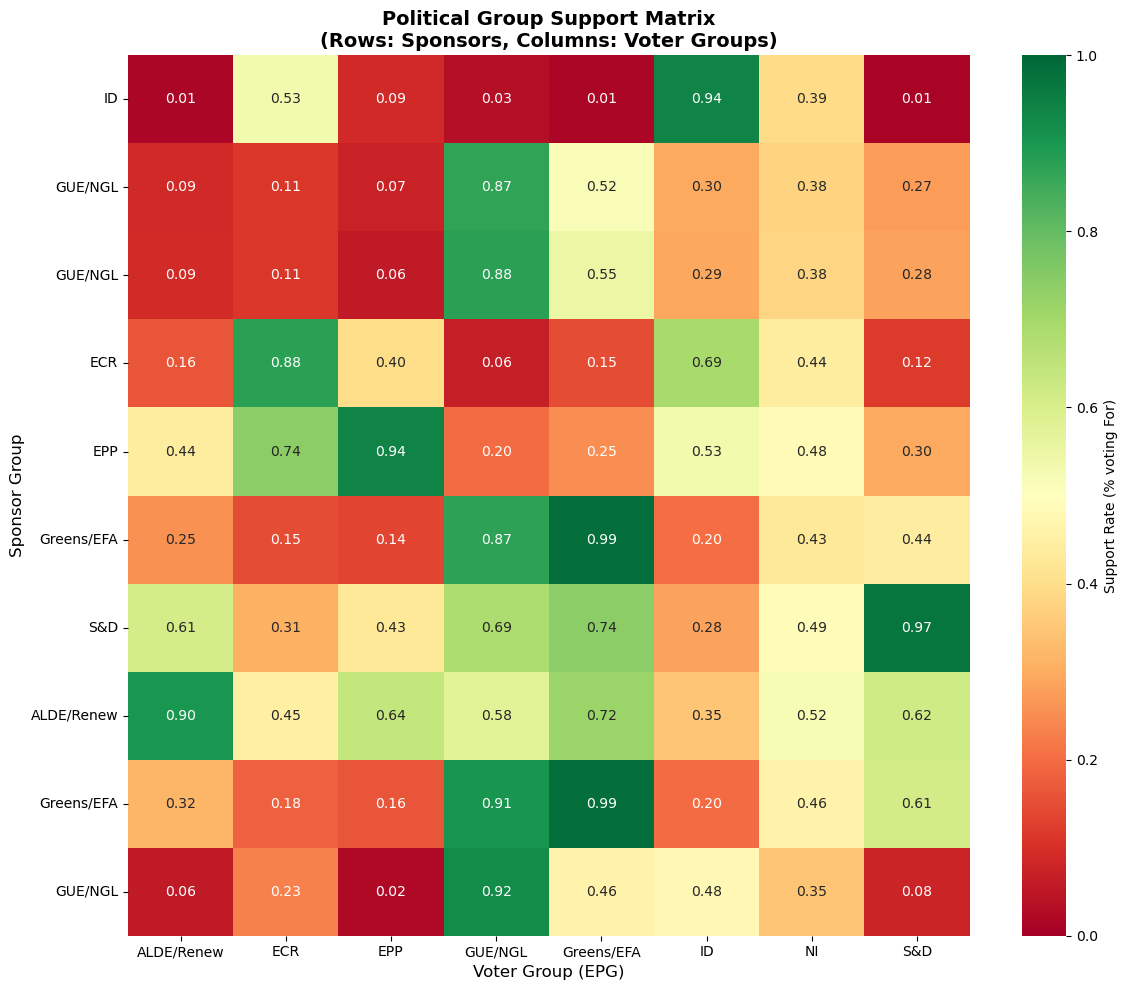


=== Group Loyalty and Alliance Analysis ===

1. In-Group Loyalty (do MEPs support their own group's proposals?):
  ID: 93.8%
  GUE/NGL: 87.0%
  GUE/NGL: 87.8%
  ECR: 87.8%
  EPP: 93.9%
  Greens/EFA: 98.7%
  S&D: 97.1%
  ALDE/Renew: 90.1%
  Greens/EFA: 98.7%
  GUE/NGL: 92.3%

2. Strongest Cross-Group Alliances (support > 60%):
  ID supports ECR: 69.3%
  ECR supports EPP: 74.2%
  GUE/NGL supports Greens/EFA: 87.1%
  ALDE/Renew supports S&D: 60.8%
  GUE/NGL supports S&D: 68.6%
  Greens/EFA supports S&D: 74.1%
  EPP supports ALDE/Renew: 64.3%
  Greens/EFA supports ALDE/Renew: 71.7%
  S&D supports ALDE/Renew: 61.8%
  GUE/NGL supports Greens/EFA: 90.6%
  S&D supports Greens/EFA: 61.1%

3. Strongest Oppositions (support < 30%):
  ALDE/Renew opposes ID: 1.2%
  EPP opposes ID: 8.8%
  GUE/NGL opposes ID: 3.4%
  Greens/EFA opposes ID: 1.2%
  S&D opposes ID: 0.9%
  ALDE/Renew opposes GUE/NGL: 9.0%
  ECR opposes GUE/NGL: 11.2%
  EPP opposes GUE/NGL: 7.2%
  ID opposes GUE/NGL: 29.6%
  S&D opposes G

{'in_group_loyalty': {'ID': 0.9384316495937831,
  'GUE/NGL': 0.9230769230769231,
  'ECR': 0.8777172069035717,
  'EPP': 0.9390025700250496,
  'Greens/EFA': 0.98698738170347,
  'S&D': 0.9708503798947984,
  'ALDE/Renew': 0.9013125911521633},
 'strongest_alliances': [{'Sponsor': 'ECR',
   'Supporter': 'ID',
   'Support_Rate': 0.6925965543139352},
  {'Sponsor': 'EPP', 'Supporter': 'ECR', 'Support_Rate': 0.741834451901566},
  {'Sponsor': 'Greens/EFA',
   'Supporter': 'GUE/NGL',
   'Support_Rate': 0.8713790469475292},
  {'Sponsor': 'S&D',
   'Supporter': 'ALDE/Renew',
   'Support_Rate': 0.6084003938745713},
  {'Sponsor': 'S&D',
   'Supporter': 'GUE/NGL',
   'Support_Rate': 0.6861976847729296},
  {'Sponsor': 'S&D',
   'Supporter': 'Greens/EFA',
   'Support_Rate': 0.7411064252046639},
  {'Sponsor': 'ALDE/Renew',
   'Supporter': 'EPP',
   'Support_Rate': 0.6432516015020985},
  {'Sponsor': 'ALDE/Renew',
   'Supporter': 'Greens/EFA',
   'Support_Rate': 0.7173707440100883},
  {'Sponsor': 'ALDE/Rene

In [90]:
# Analyze just EP9
analyzer_ep9 = MEPSimilarityAnalyzer(
    rcv_files=['EP-voting-data/EP9_RCVs_2022_06_22.xlsx'],
    voted_docs_files=['EP-voting-data/EP9_Voted_docs.xlsx'],
    device='cpu'
)

analyzer_ep9.load_data()
analyzer_ep9.preprocess_data(min_participation_rate=0.5)
analyzer_ep9.load_vote_metadata()
analyzer_ep9.compute_support_matrix(sponsor_col='Author', min_votes=10)
analyzer_ep9.visualize_support_heatmap()
analyzer_ep9.analyze_group_loyalty_and_alliances()